<a href="https://colab.research.google.com/github/Rishii077/AI-Lab-Assignments/blob/main/Experiment_8_Image_Retrieval_Visual_QA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 7.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.


In [2]:
from google.colab import userdata
from google import genai

API_KEY = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=API_KEY)

print("Gemini connected successfully!")

Gemini connected successfully!


In [3]:
from PIL import Image, ImageDraw

def create_sample_image(filename, background, objects):
    image = Image.new("RGB", (500, 350), background)
    draw = ImageDraw.Draw(image)

    y = 50

    for obj in objects:
        draw.text((50, y), obj, fill="black")
        y += 50

    image.save(filename)


create_sample_image(
    "image1.png",
    "lightblue",
    ["Image 1", "A red car", "A road", "Trees"]
)

create_sample_image(
    "image2.png",
    "lightgreen",
    ["Image 2", "A dog", "A ball", "Grass"]
)

create_sample_image(
    "image3.png",
    "lightyellow",
    ["Image 3", "A laptop", "A desk", "A coffee cup"]
)

print("Sample images created successfully!")

Sample images created successfully!


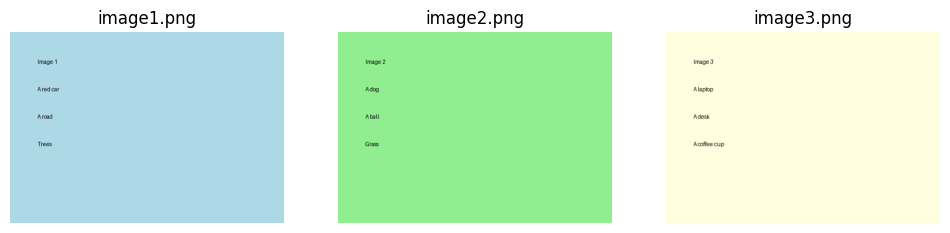

In [4]:
import matplotlib.pyplot as plt

image_files = ["image1.png", "image2.png", "image3.png"]

plt.figure(figsize=(12, 4))

for i, file in enumerate(image_files):
    image = Image.open(file)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(file)

plt.show()

In [7]:
import base64

def describe_image(image_path):

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_data = base64.b64encode(image_bytes).decode("utf-8")

    prompt = """
Describe this image in a short and simple way.

Mention:
- Main objects
- Environment
- Important visual details
"""

    interaction = client.interactions.create(
        model="gemini-3.6-flash",
        input=[
            {
                "type": "text",
                "text": prompt
            },
            {
                "type": "image",
                "data": image_data,
                "mime_type": "image/png"
            }
        ]
    )

    return interaction.output_text.strip()

In [8]:
description = describe_image("image1.png")

print("========== IMAGE DESCRIPTION ==========")
print(description)

========== IMAGE DESCRIPTION ==========
Here is a description of the image:

* **Main objects:** The image contains black text labels arranged vertically on the left side reading: *"Image 1"*, *"A red car"*, *"A road"*, and *"Trees"*. There are no actual pictures of these objects, only the text listing them.
* **Environment:** A minimal, plain, solid light-blue background.
* **Important visual details:** Simple, dark sans-serif text left-aligned against a clear, uniform blue canvas.


In [9]:
image_descriptions = {
    "image1.png": "A red car on a road with trees.",
    "image2.png": "A dog playing with a ball on grass.",
    "image3.png": "A laptop on a desk with a coffee cup."
}

print("Image descriptions stored successfully!")

Image descriptions stored successfully!


In [10]:
def retrieve_image(query):
    query = query.lower()

    scores = {}

    for image, description in image_descriptions.items():
        words = query.split()

        score = sum(
            1 for word in words
            if word in description.lower()
        )

        scores[image] = score

    best_image = max(scores, key=scores.get)

    return best_image

In [11]:
query = "Which image contains a dog?"

retrieved_image = retrieve_image(query)

print("========== IMAGE RETRIEVAL ==========")
print("User Query:", query)
print("Retrieved Image:", retrieved_image)

========== IMAGE RETRIEVAL ==========
User Query: Which image contains a dog?
Retrieved Image: image1.png


In [12]:
import base64

def visual_question_answering(question):

    # Retrieve the most relevant image
    retrieved_image = retrieve_image(question)

    # Read image
    with open(retrieved_image, "rb") as f:
        image_bytes = f.read()

    image_data = base64.b64encode(image_bytes).decode("utf-8")

    prompt = f"""
You are a Visual Question Answering system.

Answer the user's question based on the provided image.

User Question:
{question}

Give a short and clear answer.
"""

    interaction = client.interactions.create(
        model="gemini-3.6-flash",
        input=[
            {
                "type": "text",
                "text": prompt
            },
            {
                "type": "image",
                "data": image_data,
                "mime_type": "image/png"
            }
        ]
    )

    answer = interaction.output_text.strip()

    print("========== VISUAL QA SYSTEM ==========")
    print("\nUser Question:")
    print(question)

    print("\nRetrieved Image:")
    print(retrieved_image)

    print("\nAnswer:")
    print(answer)

    return answer

In [13]:
visual_question_answering(
    "Which image contains a dog?"
)

========== VISUAL QA SYSTEM ==========

User Question:
Which image contains a dog?

Retrieved Image:
image1.png

Answer:
Based on the provided text description, **none** of the images contain a dog (Image 1 contains a red car, a road, and trees).


'Based on the provided text description, **none** of the images contain a dog (Image 1 contains a red car, a road, and trees).'